##Import các thư viện cần thiết

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Đã import các thư viện cần thiết")

Đã import các thư viện cần thiết


##Xử lý làm giảm số chiều của dữ **liệu**

In [ ]:
# Import dataset
df = pd.read_csv("/content/drive/MyDrive/Học liệu/2025.1/Project 1/dataset.csv")

# Thông tin của dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 80 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Unnamed: 0                    int64  
 1    Destination Port             int64  
 2    Flow Duration                int64  
 3    Total Fwd Packets            int64  
 4    Total Backward Packets       int64  
 5   Total Length of Fwd Packets   int64  
 6    Total Length of Bwd Packets  int64  
 7    Fwd Packet Length Max        int64  
 8    Fwd Packet Length Min        int64  
 9    Fwd Packet Length Mean       float64
 10   Fwd Packet Length Std        float64
 11  Bwd Packet Length Max         int64  
 12   Bwd Packet Length Min        int64  
 13   Bwd Packet Length Mean       float64
 14   Bwd Packet Length Std        float64
 15  Flow Bytes/s                  float64
 16   Flow Packets/s               float64
 17   Flow IAT Mean                float64
 18   Flow IAT Std         

In [ ]:
df.head()

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,49188,4,2,0,12,0,6,6,6.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,1,49188,1,2,0,12,0,6,6,6.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,2,49188,1,2,0,12,0,6,6,6.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,3,49188,1,2,0,12,0,6,6,6.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,4,49486,3,2,0,12,0,6,6,6.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


/tmp/ipython-input-895561.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=' Label', order=order, palette='viridis')


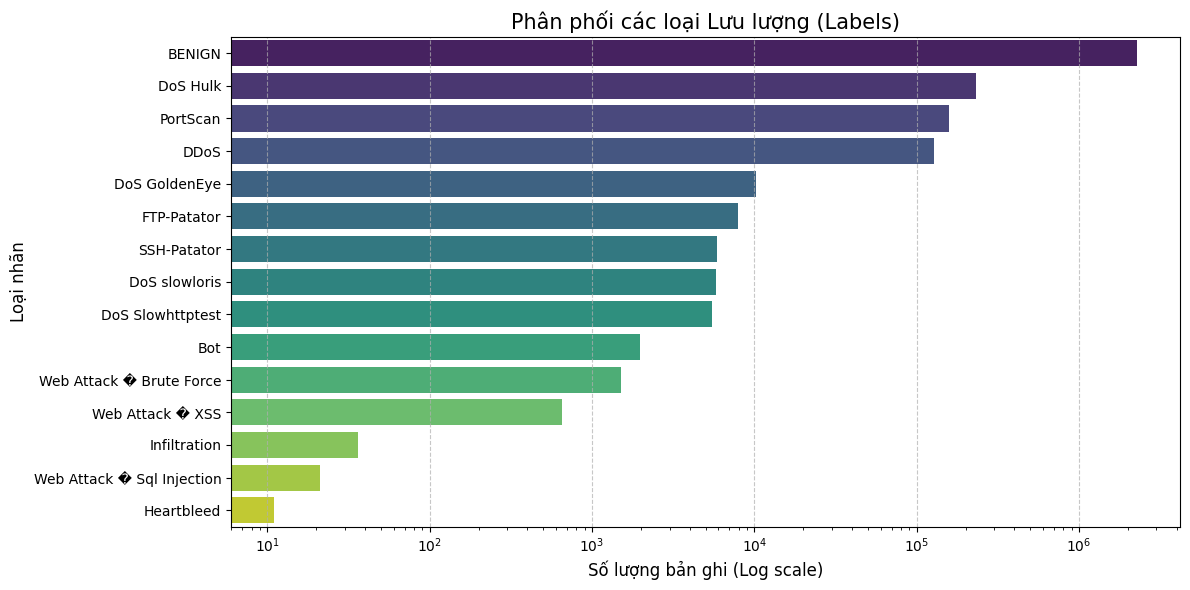

In [ ]:
plt.figure(figsize=(12, 6))
# Vẽ biểu đồ cột ngang để dễ đọc tên các loại tấn công
order = df[' Label'].value_counts().index
sns.countplot(data=df, y=' Label', order=order, palette='viridis')

plt.title('Phân phối các loại Lưu lượng (Labels)', fontsize=15)
plt.xlabel('Số lượng bản ghi (Log scale)', fontsize=12)
plt.ylabel('Loại nhãn', fontsize=12)
plt.xscale('log') # Dùng thang đo Log vì BENIGN quá lớn so với các loại khác
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=300)
plt.show()

1. Những đặc trưng có thể loại bỏ ngay

In [ ]:
# Loại bỏ cột index trước tiên
cols_to_drop = ['Unnamed: 0']
df = df.drop(columns = cols_to_drop)
print("Đã loại bỏ các cột", cols_to_drop)

Đã loại bỏ các cột ['Unnamed: 0']


In [ ]:
# Các đặc trưng: Total Length of Fwd Packets, Total Length of Bwd Packets có thể suy ra từ các đặc trưng về trung bình và số lượng
cols_to_drop = ['Total Length of Fwd Packets', ' Total Length of Bwd Packets']
df = df.drop(columns = cols_to_drop)
print("Đã loại bỏ các cột", cols_to_drop)

Đã loại bỏ các cột ['Total Length of Fwd Packets', ' Total Length of Bwd Packets']


In [ ]:
# Các đặc trưng tốc độ: Flow Bytes/s, Flow Packets/s, Fwd Packets/s, Bwd Packets/s.
# Các đặc trưng về tốc độ có thể suy ra từ các đặc trưng khác nên cũng cần loại bỏ
cols_to_drop = ['Flow Bytes/s', ' Flow Packets/s', 'Fwd Packets/s', ' Bwd Packets/s']
df = df.drop(columns = cols_to_drop)
print("Đã loại bỏ các cột", cols_to_drop)

Đã loại bỏ các cột ['Flow Bytes/s', ' Flow Packets/s', 'Fwd Packets/s', ' Bwd Packets/s']


In [ ]:
# Các đặc trưng packet: Min Packet Length, Max Packet Length, Packet Length Mean/Std/Variance, Average Packet Size.
# Các đặc trưng về packet có thể suy ra từ Fwd packet và Bwd packet nên ta loại bỏ
cols_to_drop = [' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', ' Average Packet Size']
df = df.drop(columns = cols_to_drop)
print("Đã loại bỏ các cột", cols_to_drop)

Đã loại bỏ các cột [' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', ' Average Packet Size']


In [ ]:
# Các đặc trưng segment: Avg Fwd Segment Size, Avg Bwd Segment Size.
# Packet = segment + header nên ta có thể loại bỏ các đặc trưng về segment
cols_to_drop = [' Avg Fwd Segment Size', ' Avg Bwd Segment Size']
df = df.drop(columns = cols_to_drop)
print("Đã loại bỏ các cột", cols_to_drop)

Đã loại bỏ các cột [' Avg Fwd Segment Size', ' Avg Bwd Segment Size']


In [ ]:
# Header: Fwd/Bwd Header Length.
# Các header thường có độ dài không đổi nên ta cũng có thể bỏ.
cols_to_drop = [' Fwd Header Length',' Bwd Header Length']
df = df.drop(columns = cols_to_drop)
print("Đã loại bỏ các cột", cols_to_drop)

Đã loại bỏ các cột [' Fwd Header Length', ' Bwd Header Length']


In [ ]:
# Sau khi xử lý các đặc trưng 'rác', các đặc trưng còn lại bao gồm
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 63 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0    Destination Port         int64  
 1    Flow Duration            int64  
 2    Total Fwd Packets        int64  
 3    Total Backward Packets   int64  
 4    Fwd Packet Length Max    int64  
 5    Fwd Packet Length Min    int64  
 6    Fwd Packet Length Mean   float64
 7    Fwd Packet Length Std    float64
 8   Bwd Packet Length Max     int64  
 9    Bwd Packet Length Min    int64  
 10   Bwd Packet Length Mean   float64
 11   Bwd Packet Length Std    float64
 12   Flow IAT Mean            float64
 13   Flow IAT Std             float64
 14   Flow IAT Max             int64  
 15   Flow IAT Min             int64  
 16  Fwd IAT Total             int64  
 17   Fwd IAT Mean             float64
 18   Fwd IAT Std              float64
 19   Fwd IAT Max              int64  
 20   Fwd IAT Min            

2. Xử lý để loại bỏ thêm

In [ ]:
# Tính mean để xem có cột nào không mang dữ liệu không
# Xóa các đặc trưng có mean = 0
df_numeric = df.select_dtypes(include=['number'])  # chỉ lấy cột số, trừ cột label
mean_values = df_numeric.mean()
cols_to_drop = mean_values[mean_values == 0].index.tolist()
print("Các cột có mean = 0:", cols_to_drop)

Các cột có mean = 0: [' Bwd PSH Flags', ' Bwd URG Flags', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [ ]:
# Xóa các cột có mean = 0
df = df.drop(columns = cols_to_drop)
print("Đã loại bỏ các cột", cols_to_drop)

Đã loại bỏ các cột [' Bwd PSH Flags', ' Bwd URG Flags', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [ ]:
# Tính ma trận tương quan để kiểm tra mức độ liên hệ giữa các đặc trưng còn lại
corr_matrix = df_numeric.corr()

# Hiển thị các cặp đặc trưng có tương quan cao
threshold = 0.99
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

# In ra các cặp có tương quan cao
print("Các cặp đặc trưng có tương quan:")
for item in high_corr:
    print(item)

Các cặp đặc trưng có tương quan:
(' Flow Duration', 'Fwd IAT Total', np.float64(0.998559932630955))
(' Total Fwd Packets', ' Total Backward Packets', np.float64(0.9990699513709503))
(' Total Fwd Packets', 'Subflow Fwd Packets', np.float64(1.0))
(' Total Fwd Packets', ' Subflow Bwd Packets', np.float64(0.9990699513709503))
(' Total Fwd Packets', ' Subflow Bwd Bytes', np.float64(0.9969866573971401))
(' Total Backward Packets', 'Subflow Fwd Packets', np.float64(0.9990699513709504))
(' Total Backward Packets', ' Subflow Bwd Packets', np.float64(1.0))
(' Total Backward Packets', ' Subflow Bwd Bytes', np.float64(0.9944241078556847))
(' Flow IAT Max', ' Fwd IAT Max', np.float64(0.9980843380303378))
('Fwd PSH Flags', ' SYN Flag Count', np.float64(1.0))
(' Fwd URG Flags', ' CWE Flag Count', np.float64(1.0))
(' RST Flag Count', ' ECE Flag Count', np.float64(0.997820027929298))
('Subflow Fwd Packets', ' Subflow Bwd Packets', np.float64(0.9990699513709503))
('Subflow Fwd Packets', ' Subflow Bwd By

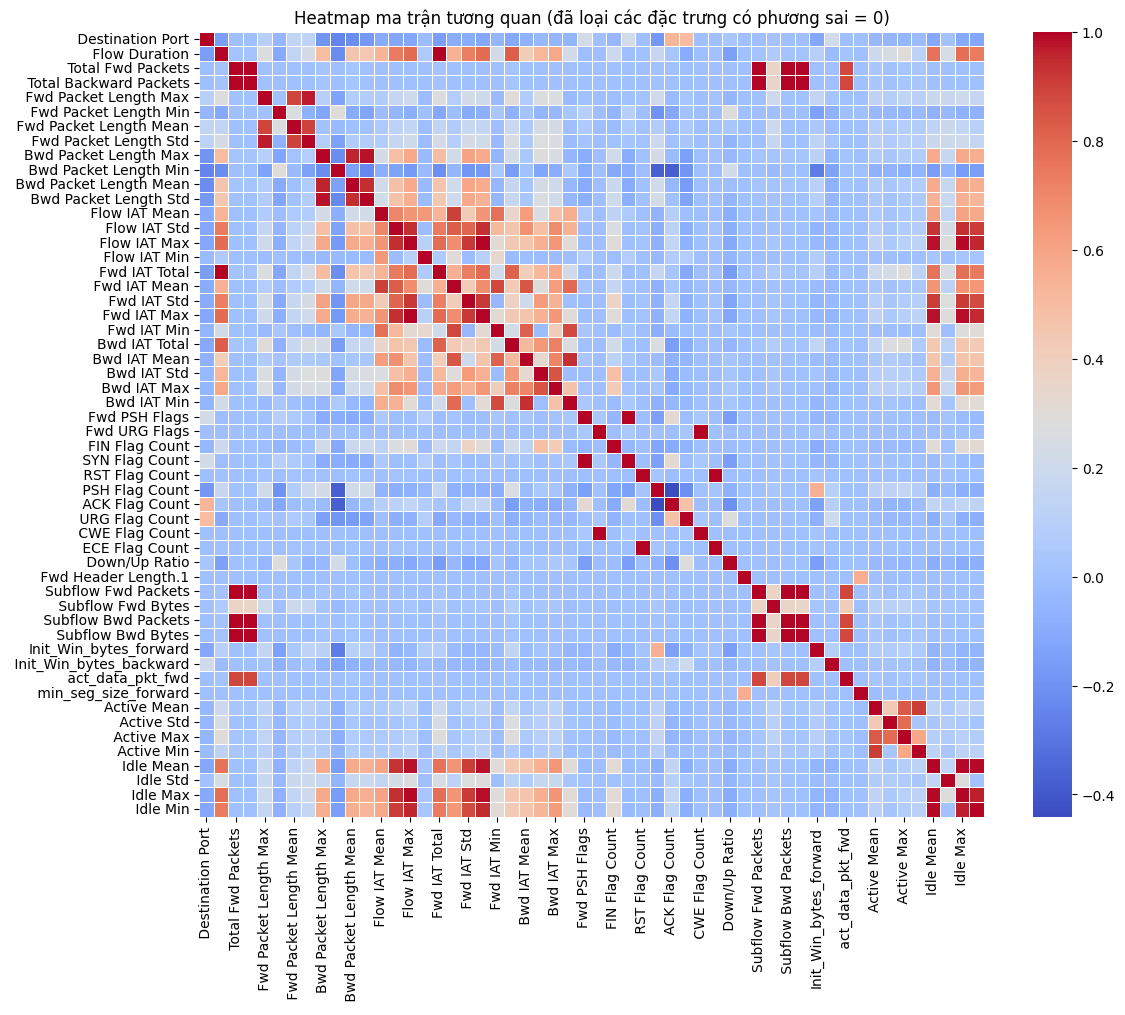

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loại các cột có phương sai = 0 (chỉ 1 giá trị duy nhất)
df_no_zero_var = df_numeric.loc[:, df_numeric.nunique() > 1]

# 2. Tính lại ma trận tương quan
corr_matrix = df_no_zero_var.corr()

# 3. Vẽ heatmap (chỉ màu, không hiện số)
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Heatmap ma trận tương quan (đã loại các đặc trưng có phương sai = 0)")
plt.tight_layout()
plt.show()


In [ ]:
# Bỏ một trong các đặc trưng có hệ số tương quan 1.0
cols_to_drop = ['Subflow Fwd Packets', ' Subflow Bwd Packets', ' SYN Flag Count', ' CWE Flag Count']
df = df.drop(columns = cols_to_drop)
print("Đã loại bỏ các cột", cols_to_drop)

Đã loại bỏ các cột ['Subflow Fwd Packets', ' Subflow Bwd Packets', ' SYN Flag Count', ' CWE Flag Count']


In [ ]:
# Tính phương sai để xem độ biến động của dữ liệu quanh mean
df_numeric = df.select_dtypes(include=['number'])  # chỉ lấy cột số, trừ cột label
var_values = df_numeric.var()
cols_to_drop = var_values[var_values == 0].index.tolist()
print("Các cột có var = 0:", cols_to_drop)

Các cột có var = 0: []


# Các đặc trung cuối cùng

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 51 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0    Destination Port         int64  
 1    Flow Duration            int64  
 2    Total Fwd Packets        int64  
 3    Total Backward Packets   int64  
 4    Fwd Packet Length Max    int64  
 5    Fwd Packet Length Min    int64  
 6    Fwd Packet Length Mean   float64
 7    Fwd Packet Length Std    float64
 8   Bwd Packet Length Max     int64  
 9    Bwd Packet Length Min    int64  
 10   Bwd Packet Length Mean   float64
 11   Bwd Packet Length Std    float64
 12   Flow IAT Mean            float64
 13   Flow IAT Std             float64
 14   Flow IAT Max             int64  
 15   Flow IAT Min             int64  
 16  Fwd IAT Total             int64  
 17   Fwd IAT Mean             float64
 18   Fwd IAT Std              float64
 19   Fwd IAT Max              int64  
 20   Fwd IAT Min            

In [ ]:
# Lưu dataset: data.csv  => huấn luyện các mô hình
df.to_csv("/content/drive/MyDrive/Học liệu/2025.1/Project 1/data.csv", index=False)

KeyboardInterrupt: 

## Xử lý tiếp nhãn

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Học liệu/2025.1/Project 1/data_reduced.csv")

In [ ]:
df[' Label'].value_counts()

,count
Label,
BENIGN,681929
DoS Hulk,231073
PortScan,158930
DDoS,128027
DoS GoldenEye,10293
FTP-Patator,7938
SSH-Patator,5897
DoS slowloris,5796
DoS Slowhttptest,5499


In [ ]:
def merge_label(label):
    if label == "BENIGN":
        return "BENIGN"

    # DoS group
    if label in ["DoS Hulk", "DDoS", "DoS GoldenEye", "DoS slowloris", "DoS Slowhttptest"]:
        return "DoS"

    # PortScan
    if label == "PortScan":
        return "PortScan"

    # Brute Force group
    if label in ["FTP-Patator", "SSH-Patator"]:
        return "Brute Force"

    # Web Attacks
    if "Web Attack" in label:
        return "Web Attack"

    # Botnet
    if label == "Bot":
        return "Bot"

    # Infiltration
    if label == "Infiltration":
        return "Infiltration"

    # Heartbleed
    if label == "Heartbleed":
        return "Heartbleed"

    return label

# ghi đè trực tiếp lên cột Label
df[' Label'] = df[' Label'].apply(merge_label)

In [ ]:
df[' Label'].value_counts()

,count
Label,
BENIGN,681929
DoS,380688
PortScan,158930
Brute Force,13835
Web Attack,2180
Bot,1966
Infiltration,36
Heartbleed,11


In [ ]:
df.to_csv("/content/drive/MyDrive/Học liệu/2025.1/Project 1/datafinal.csv", index=False)

In [ ]:
df.shape


(1239575, 50)

In [ ]:
df.head()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,5577389,5,1,46,0,24.600000,23.276598,46,46,...,32,37015.0,0.0000,37015,37015,5527113.0,0.000,5527113,5527113,BENIGN
1,51251,6608534,1,6,6,6,6.000000,0.000000,6,6,...,20,26568.0,0.0000,26568,26568,6581966.0,0.000,6581966,6581966,BENIGN
2,53,888,2,2,31,31,31.000000,0.000000,123,123,...,32,0.0,0.0000,0,0,0.0,0.000,0,0,BENIGN
3,53022,198,3,1,31,0,10.333333,17.897858,6,6,...,32,0.0,0.0000,0,0,0.0,0.000,0,0,BENIGN
4,443,116657713,24,25,579,0,54.916667,158.710816,1418,0,...,32,330945.5,415998.6975,625101,36790,58000000.0,1250244.692,58800000,57100000,BENIGN


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1239575 entries, 0 to 1239574
Data columns (total 50 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0    Destination Port         1239575 non-null  int64  
 1    Flow Duration            1239575 non-null  int64  
 2    Total Fwd Packets        1239575 non-null  int64  
 3    Total Backward Packets   1239575 non-null  int64  
 4    Fwd Packet Length Max    1239575 non-null  int64  
 5    Fwd Packet Length Min    1239575 non-null  int64  
 6    Fwd Packet Length Mean   1239575 non-null  float64
 7    Fwd Packet Length Std    1239575 non-null  float64
 8   Bwd Packet Length Max     1239575 non-null  int64  
 9    Bwd Packet Length Min    1239575 non-null  int64  
 10   Bwd Packet Length Mean   1239575 non-null  float64
 11   Bwd Packet Length Std    1239575 non-null  float64
 12   Flow IAT Mean            1239575 non-null  float64
 13   Flow IAT Std             1

In [ ]:
df.describe()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1.239575e+06,1.239575e+06,1.239575e+06,1.239575e+06,1.239575e+06,1.239575e+06,1.239575e+06,1.239575e+06,1.239575e+06,1.239575e+06,...,1.239575e+06,1.239575e+06,1.239575e+06,1.239575e+06,1.239575e+06,1.239575e+06,1.239575e+06,1.239575e+06,1.239575e+06,1.239575e+06
mean,6.332280e+03,1.935921e+07,6.936934e+00,7.150069e+00,1.784260e+02,1.346852e+01,4.764105e+01,6.165595e+01,1.480467e+03,2.866894e+01,...,3.763568e+00,-2.612721e+03,8.780904e+04,3.410153e+04,1.409291e+05,6.761548e+04,1.417465e+07,8.156474e+05,1.479465e+07,1.356693e+07
std,1.602717e+04,3.720160e+07,4.757234e+02,6.329420e+02,6.072855e+02,5.581035e+01,1.588554e+02,2.364521e+02,2.672576e+03,6.040047e+01,...,4.320780e+02,1.096516e+06,6.537560e+05,3.648723e+05,9.451118e+05,5.956722e+05,3.130430e+07,6.070337e+06,3.215035e+07,3.107533e+07
min,0.000000e+00,-1.200000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,7.900000e+01,1.000000e+00,1.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,4.130400e+04,2.000000e+00,2.000000e+00,3.100000e+01,0.000000e+00,2.671429e+01,0.000000e+00,7.000000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,6.859978e+06,5.000000e+00,5.000000e+00,2.010000e+02,6.000000e+00,4.875000e+01,7.342116e+01,1.460000e+03,6.000000e+00,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.281726e+06,0.000000e+00,5.281863e+06,5.159356e+06
max,6.553500e+04,1.200000e+08,2.066870e+05,2.817410e+05,2.482000e+04,2.065000e+03,5.940857e+03,7.049469e+03,1.953000e+04,1.983000e+03,...,1.980580e+05,1.380000e+02,1.060000e+08,7.050000e+07,1.060000e+08,1.060000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [ ]:
df.isnull().sum()


,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0
Bwd Packet Length Max,0
Bwd Packet Length Min,0


In [ ]:
df.columns


Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', ' Flow IAT Mean', ' Flow IAT Std',
       ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean',
       ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total',
       ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min',
       'Fwd PSH Flags', ' Fwd URG Flags', 'FIN Flag Count', ' RST Flag Count',
       ' PSH Flag Count', ' ACK Flag Count', ' URG Flag Count',
       ' ECE Flag Count', ' Down/Up Ratio', ' Subflow Fwd Bytes',
       ' Subflow Bwd Bytes', 'Init_Win_bytes_forward',
       ' Init_Win_bytes_backward', ' act_data_pkt_fwd',
       ' min_seg_size_forward', 'Active Mean', ' Active Std', ' Active Max',
       ' A

In [ ]:
df.duplicated().sum()


np.int64(167530)

array([[<Axes: title={'center': ' Destination Port'}>,
        <Axes: title={'center': ' Flow Duration'}>,
        <Axes: title={'center': ' Total Fwd Packets'}>,
        <Axes: title={'center': ' Total Backward Packets'}>,
        <Axes: title={'center': ' Fwd Packet Length Max'}>,
        <Axes: title={'center': ' Fwd Packet Length Min'}>,
        <Axes: title={'center': ' Fwd Packet Length Mean'}>],
       [<Axes: title={'center': ' Fwd Packet Length Std'}>,
        <Axes: title={'center': 'Bwd Packet Length Max'}>,
        <Axes: title={'center': ' Bwd Packet Length Min'}>,
        <Axes: title={'center': ' Bwd Packet Length Mean'}>,
        <Axes: title={'center': ' Bwd Packet Length Std'}>,
        <Axes: title={'center': ' Flow IAT Mean'}>,
        <Axes: title={'center': ' Flow IAT Std'}>],
       [<Axes: title={'center': ' Flow IAT Max'}>,
        <Axes: title={'center': ' Flow IAT Min'}>,
        <Axes: title={'center': 'Fwd IAT Total'}>,
        <Axes: title={'center': ' Fwd

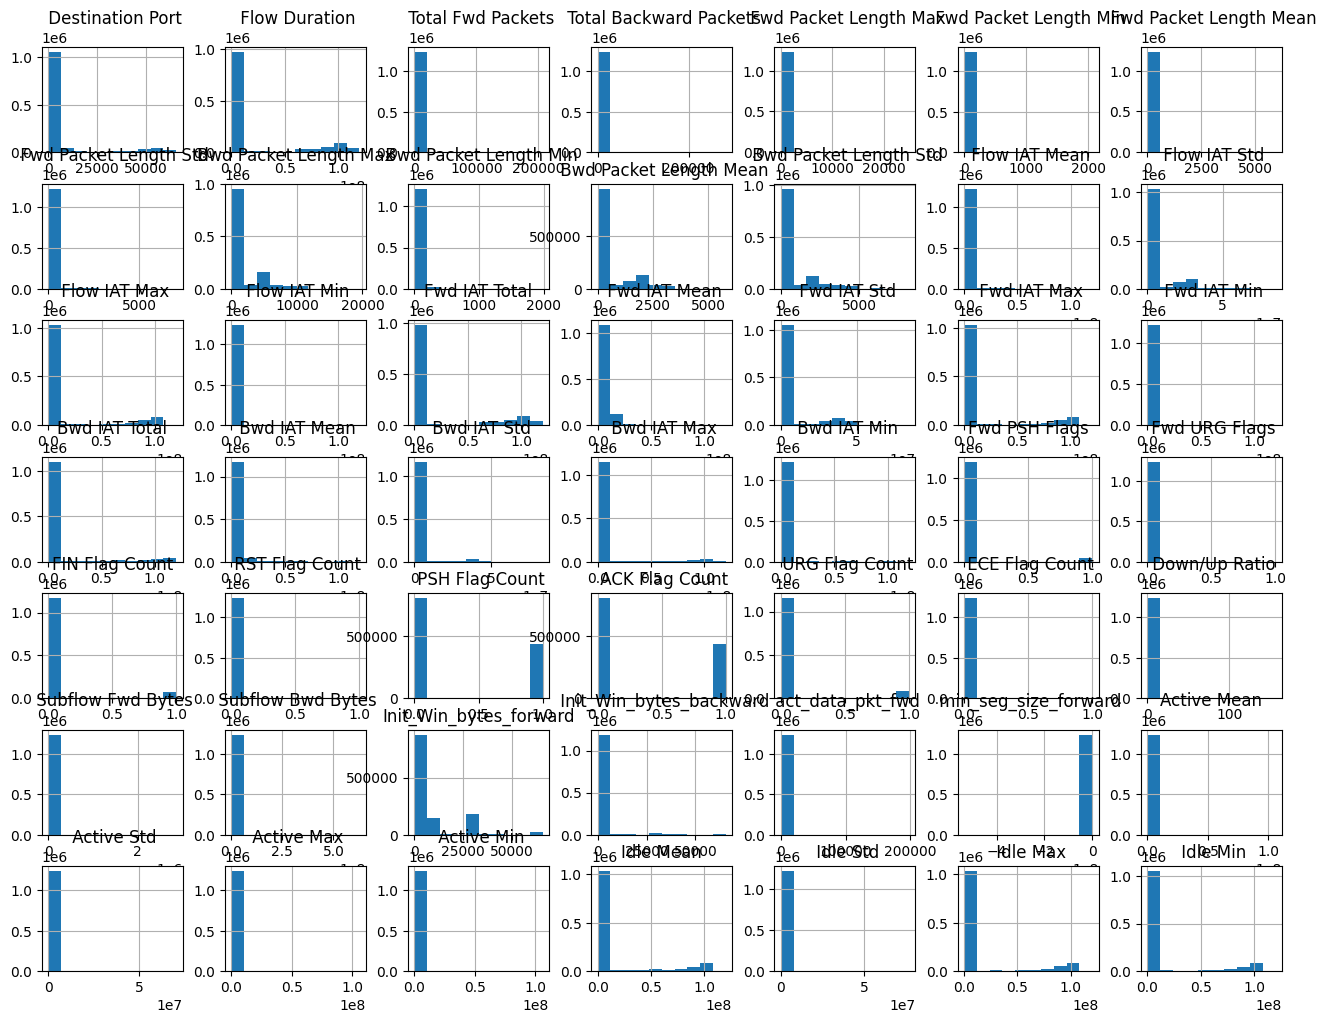

In [ ]:
df.hist(figsize=(16, 12))
